Quantum Output:
[tensor(0.42552882, requires_grad=True), tensor(-0.36257969, requires_grad=True)]


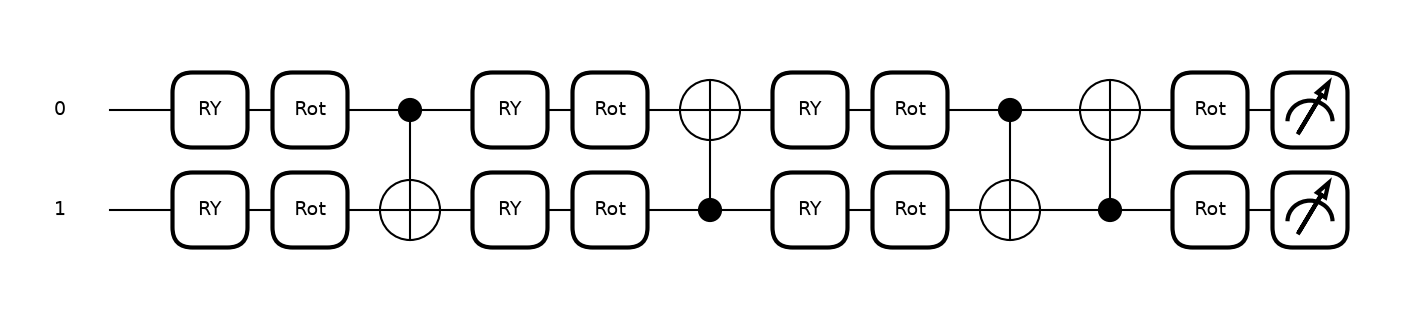

In [5]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

n_qubits = 2
n_qlayers = 1

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def vqc(inputs, weights):

    for _ in range(n_qlayers):

        # Initial Data Encoding
        qml.RY(inputs[0], wires=0)
        qml.RY(inputs[1], wires=1)

        # Variational Block 1
        qml.Rot(*weights[0], wires=0)
        qml.Rot(*weights[1], wires=1)
        qml.CNOT(wires=[0, 1])

        # Data Re-uploading
        qml.RY(inputs[0], wires=0)
        qml.RY(inputs[1], wires=1)

        # Variational Block 2
        qml.Rot(*weights[2], wires=0)
        qml.Rot(*weights[3], wires=1)
        qml.CNOT(wires=[1, 0])

        # Data Re-uploading
        qml.RY(inputs[0], wires=0)
        qml.RY(inputs[1], wires=1)

        # Variational Block 3
        qml.Rot(*weights[4], wires=0)
        qml.Rot(*weights[5], wires=1)   
        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[1, 0])

        #Variational Block 4
        qml.Rot(*weights[6], wires=0)
        qml.Rot(*weights[7], wires=1)


    return [
        qml.expval(qml.PauliZ(0)),
        qml.expval(qml.PauliZ(1))
    ]

# Inputs
inputs = np.array([0.2, 1.1], requires_grad=False)

weights = np.random.randn(8, 3, requires_grad=True)


# ==========================================
# Run Circuit
# ==========================================
output = vqc(inputs, weights)

print("Quantum Output:")
print(output)

# Draw the circuit
fig, ax = qml.draw_mpl(vqc)(inputs, weights)
plt.show()